In [ ]:
import importlib

import numpy as np
import matplotlib.pyplot as plt
import state_to_edgepoints as state_to_edgepoints_module

state_to_edgepoints_module = importlib.reload(state_to_edgepoints_module)
state_to_edgepoints = state_to_edgepoints_module.state_to_edgepoints

import sys

# go out of folder to import the CR alg
sys.path.append("..")


import algorithms as algorithms_module

algorithms_module = importlib.reload(algorithms_module)
ChristianRobinson = algorithms_module.ChristianRobinson






Center px: (640.00, 557.49)
Angular diameter: 34.670 deg
Edge points: 1930


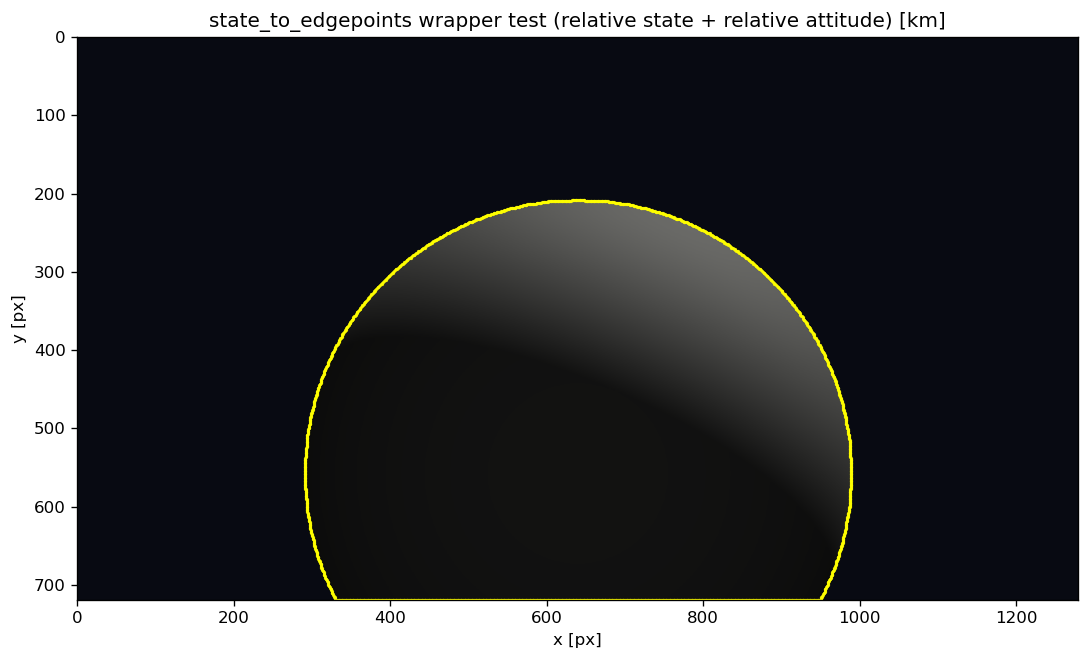

In [19]:
# Test input state
w, h = 1280, 720
K = np.array(
    [
        [1120.0, 0.0, w / 2.0],
        [0.0, 1120.0, h / 2.0],
        [0.0, 0.0, 1.0],
    ],
    dtype=np.float64,
)

# Spacecraft position is provided relative to body center [km].
spacecraft_position_relative_to_body_center = np.array([0.0, 3000.0, 5000.0], dtype=np.float64)

# Attitude offset relative to ideal center-pointing attitude.
# Identity means no offset from center-pointing.
attitude_offset_from_center_pointing = np.eye(3, dtype=np.float64)

# Add some test offset in degrees and convert to a rotation matrix.
x_offset_deg = 10
y_offset_deg = 0
z_offset_deg = 0

offset_rotation_matrix = state_to_edgepoints_module.rotation_matrix_from_euler_angles_deg(
    x_deg=x_offset_deg,
    y_deg=y_offset_deg,
    z_deg=z_offset_deg,
)

attitude_offset_from_center_pointing = offset_rotation_matrix @ attitude_offset_from_center_pointing

out = state_to_edgepoints(
    spacecraft_position_relative_to_body_center=spacecraft_position_relative_to_body_center,
    attitude_offset_from_center_pointing=attitude_offset_from_center_pointing,
    k_matrix=K,
    width=w,
    height=h,
    noise_level=0.00,
    body_center_world=np.array([0.0, 0.0, 0.0], dtype=np.float64),
    body_radius=1_737.4,
    attitude_offset_convention="world_to_camera",
    light_direction_world=np.array([.2, 0.5, 0], dtype=np.float64),
    color_tolerance=4.5,
    keep_largest_component_only=True,
    fill_internal_holes=True,
    remove_speckles=True,
)

print(f"Center px: ({out.render.center_px[0]:.2f}, {out.render.center_px[1]:.2f})")
print(f"Angular diameter: {out.render.angular_diameter_deg:.3f} deg")
print(f"Edge points: {len(out.edges.edge_coordinates_xy)}")


state_to_edgepoints_module.plot_edge_points(out, w, h)

In [20]:
# Prepare edge measurements for Christian-Robinson (CR)
# CR expects u as Nx3 homogeneous image points: [x, y, 1].
edge_xy = out.edges.edge_coordinates_xy.astype(np.float64)

if edge_xy.size == 0:
    raise ValueError("No edge points detected. Re-run rendering with less aggressive cleaning/noise.")

# Optional downsample to keep solver size manageable.
max_points_for_cr = 10000
if len(edge_xy) > max_points_for_cr:
    idx = np.linspace(0, len(edge_xy) - 1, max_points_for_cr, dtype=int)
    edge_xy_for_cr = edge_xy[idx]
else:
    edge_xy_for_cr = edge_xy

u_edge_h = np.column_stack(
    (
        edge_xy_for_cr[:, 0],
        edge_xy_for_cr[:, 1],
        np.ones(len(edge_xy_for_cr), dtype=np.float64),
    )
)

# Build T_p_c (celestial/world -> camera) from camera axes in world coordinates.
fwd = out.camera.forward_world.astype(np.float64)
up = out.camera.up_world.astype(np.float64)
right = np.cross(fwd, up)
right = right / np.linalg.norm(right)
up = np.cross(right, fwd)
up = up / np.linalg.norm(up)
fwd = fwd / np.linalg.norm(fwd)
T_p_c = np.stack((right, up, fwd), axis=0)

# Optional camera-frame rays for inspection (not directly required by CR.run).
K_inv = np.linalg.inv(K)
edge_points_camera_frame = (K_inv @ u_edge_h.T).T

print(f"Using {len(u_edge_h)} edge points for CR")
print(f"u_edge_h shape: {u_edge_h.shape}")
print(f"T_p_c shape: {T_p_c.shape}")
print(f"edge_points_camera_frame shape: {edge_points_camera_frame.shape}")

Using 1930 edge points for CR
u_edge_h shape: (1930, 3)
T_p_c shape: (3, 3)
edge_points_camera_frame shape: (1930, 3)


In [21]:
# Run Christian-Robinson using prepared edge points
# NOTE: a, b, c should match body scale units used in simulation [km].

K_inv = np.linalg.inv(K)
body_radius = 1_737.4
a, b, c = body_radius, body_radius, body_radius

CR = ChristianRobinson(K_inv, a, b, c)
r_c_est = CR.run(u_edge_h, T_p_c)

# Compare in both frames
actual_r_world = -spacecraft_position_relative_to_body_center.reshape(3, 1)
actual_r_cam = T_p_c @ actual_r_world
r_world_est = T_p_c.T @ r_c_est

print("Estimated r (camera frame) [km]:")
print(r_c_est.T)
print(f"Estimated camera-frame distance norm [km]: {float(np.linalg.norm(r_c_est)):.3f}")

print("\nWorld-frame comparison [km]:")
print(f"Actual world r:      {actual_r_world.T}")
print(f"Estimated world r:   {r_world_est.T}")
print(f"World error norm [km]:    {float(np.linalg.norm(r_world_est - actual_r_world)):.6f}")

print("\nCamera-frame comparison [km]:")
print(f"Actual camera r:     {actual_r_cam.T}")
print(f"Estimated camera r:  {r_c_est.T}")
print(f"Camera error norm [km]:   {float(np.linalg.norm(r_c_est - actual_r_cam)):.6f}")

Estimated r (camera frame) [km]:
[[1.27050947e-11 7.63349688e+02 6.45276968e+03]]
Estimated camera-frame distance norm [km]: 6497.764

World-frame comparison [km]:
Actual world r:      [[   -0. -3000. -5000.]]
Estimated world r:   [[ 1.27050947e-11 -1.59583344e+03 -6.29875027e+03]]
World error norm [km]:    1912.703837

Camera-frame comparison [km]:
Actual camera r:     [[    0.         -1012.5341706   5742.36663348]]
Estimated camera r:  [[1.27050947e-11 7.63349688e+02 6.45276968e+03]]
Camera error norm [km]:   1912.703837
